# ROC-AUC vs Average Precision — Score Relationship Study

**Question:** What is the relationship between the scores of two models —
one trained maximising **ROC-AUC**, another maximising **Average Precision (AP)**?
How does that relationship change with:

- **Class imbalance** (positive fraction `p_pos`)?
- **Feature information level** (signal strength, using 2 features only)?

**Design:**

| Element | Choice |
|---------|--------|
| DGP | Gaussian binary: `xj \| y=k ~ N(k·info_j, 1)` |
| Features | `x1`, `x2` (2 features) |
| Model A | HistGradientBoosting — early stopping on **ROC-AUC** |
| Model B | HistGradientBoosting — early stopping on **Avg Precision** |
| Study 1 | Vary `p_pos` ∈ [0.02 … 0.50], fixed info |
| Study 2 | Vary info level ∈ [0.1 … 1.8], fixed `p_pos = 0.10` |
| Repeats | 40 independent test draws per condition (n_test = 5 000) |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
import warnings
warnings.filterwarnings("ignore")

# ── style ──────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="colorblind", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})

PALETTE  = {"auc_model": "#2563eb", "ap_model": "#dc2626"}
LABELS   = {"auc_model": "AUC-trained", "ap_model": "AP-trained"}
MARKERS  = {"auc_model": "o",          "ap_model": "s"}
MNAMES   = ["auc_model", "ap_model"]


## Experiment building blocks

### Data-generating process
We use a controlled Gaussian DGP with **2 features**:

```
y  ~  Bernoulli(p_pos)
xj | y=0  ~  N(0, σ)
xj | y=1  ~  N(info_j · σ, σ)
```

`info_j` is the *signal-strength* knob — larger values mean the two class
distributions overlap less and the feature is more informative.

### Models
Both models use the same architecture (HistGradientBoosting) but differ in
their **early-stopping criterion**, which is the training objective that is
maximised on a held-out fraction of the training set:

- **AUC-trained:** `scoring="roc_auc"` → model stops when AUC on its validation split stops improving
- **AP-trained:**  `scoring="average_precision"` → same, but for AP


In [2]:
# ─── Data generating process ──────────────────────────────────────────────────
def sample_dgp(p_pos, info: dict, n: int, seed: int, sigma: float = 1.0):
    """
    Gaussian binary DGP (2 features).

    y  ~ Bernoulli(p_pos)
    xj | y=0 ~ N(0, sigma)
    xj | y=1 ~ N(info_j * sigma, sigma)

    Parameters
    ----------
    info : dict  feature_name -> separation coefficient
    """
    rng = np.random.default_rng(seed)
    y   = rng.binomial(1, p_pos, n)
    X   = np.column_stack([
        rng.normal(np.where(y == 1, v * sigma, 0.0), sigma)
        for v in info.values()
    ])
    return X, y.astype(float)


# ─── Model factories ──────────────────────────────────────────────────────────
def _hgb(scoring: str, seed: int = 42) -> HistGradientBoostingClassifier:
    """HGB with early stopping tuned to `scoring`."""
    return HistGradientBoostingClassifier(
        max_iter=500,
        learning_rate=0.05,
        max_leaf_nodes=15,
        early_stopping=True,
        scoring=scoring,
        validation_fraction=0.15,
        n_iter_no_change=20,
        random_state=seed,
    )

MODEL_FACTORIES = {
    "auc_model": lambda: _hgb("roc_auc"),
    "ap_model":  lambda: _hgb("average_precision"),
}


# ─── Experiment runner ────────────────────────────────────────────────────────
def run_condition(
    p_pos: float,
    info: dict,
    n_train: int = 3_000,
    n_test:  int = 5_000,
    n_repeats: int = 40,
    seed_offset: int = 0,
) -> pd.DataFrame:
    """
    Fit AUC-trained and AP-trained models on one shared training set,
    then score both on n_repeats independent test draws.

    Returns tidy DataFrame — one row per (model, repeat).
    """
    X_tr, y_tr = sample_dgp(p_pos, info, n_train, seed=seed_offset)

    models = {name: factory() for name, factory in MODEL_FACTORIES.items()}
    for m in models.values():
        m.fit(X_tr, y_tr)

    rows = []
    for r in range(n_repeats):
        X_te, y_te = sample_dgp(p_pos, info, n_test, seed=seed_offset + 10_000 + r)
        for name, model in models.items():
            p_hat = model.predict_proba(X_te)[:, 1]
            rows.append({
                "model":    name,
                "repeat":   r,
                "roc_auc":  roc_auc_score(y_te, p_hat),
                "avg_prec": average_precision_score(y_te, p_hat),
            })

    return pd.DataFrame(rows)


---
## Study 1 — Effect of Class Imbalance

Sweep `p_pos` from 2 % to 50 % (very rare positives → balanced).
Feature information is fixed at a moderate level: `x1_info = 0.8`, `x2_info = 0.5`.

**Hypothesis:**
- ROC-AUC is largely *invariant* to class imbalance (it measures rank order, not absolute precision).
- Average Precision is *sensitive* to imbalance — even a perfect rank ordering yields low AP when positives are rare.
- The two models should diverge more under high imbalance.


In [3]:
FIXED_INFO = {"x1": 0.8, "x2": 0.5}
P_POS_GRID = [0.02, 0.05, 0.10, 0.20, 0.35, 0.50]

print("Study 1 · class imbalance sweep")
print(f"  features   : x1 (info=0.8), x2 (info=0.5)")
print(f"  p_pos grid : {P_POS_GRID}")
print(f"  n_train=3 000,  n_test=5 000,  n_repeats=40\n")

parts1 = []
for i, p_pos in enumerate(P_POS_GRID):
    df = run_condition(p_pos, FIXED_INFO, n_repeats=40, seed_offset=i * 100)
    df["p_pos"] = p_pos
    parts1.append(df)
    summary = df.groupby("model")[["roc_auc", "avg_prec"]].mean().round(3)
    print(f"  p_pos={p_pos:.2f}  expected_pos_train≈{int(3000*p_pos):4d}  |  {summary.to_dict()}")

study1 = pd.concat(parts1, ignore_index=True)
print(f"\n✓  study1: {len(study1):,} rows")


Study 1 · class imbalance sweep
  features   : x1 (info=0.8), x2 (info=0.5)
  p_pos grid : [0.02, 0.05, 0.1, 0.2, 0.35, 0.5]
  n_train=3 000,  n_test=5 000,  n_repeats=40



  p_pos=0.02  expected_pos_train≈  60  |  {'roc_auc': {'ap_model': 0.7, 'auc_model': 0.7}, 'avg_prec': {'ap_model': 0.047, 'auc_model': 0.047}}


  p_pos=0.05  expected_pos_train≈ 150  |  {'roc_auc': {'ap_model': 0.716, 'auc_model': 0.714}, 'avg_prec': {'ap_model': 0.126, 'auc_model': 0.126}}


  p_pos=0.10  expected_pos_train≈ 300  |  {'roc_auc': {'ap_model': 0.716, 'auc_model': 0.716}, 'avg_prec': {'ap_model': 0.24, 'auc_model': 0.237}}


  p_pos=0.20  expected_pos_train≈ 600  |  {'roc_auc': {'ap_model': 0.728, 'auc_model': 0.722}, 'avg_prec': {'ap_model': 0.405, 'auc_model': 0.399}}


  p_pos=0.35  expected_pos_train≈1050  |  {'roc_auc': {'ap_model': 0.733, 'auc_model': 0.732}, 'avg_prec': {'ap_model': 0.594, 'auc_model': 0.594}}


  p_pos=0.50  expected_pos_train≈1500  |  {'roc_auc': {'ap_model': 0.734, 'auc_model': 0.737}, 'avg_prec': {'ap_model': 0.723, 'auc_model': 0.724}}

✓  study1: 480 rows


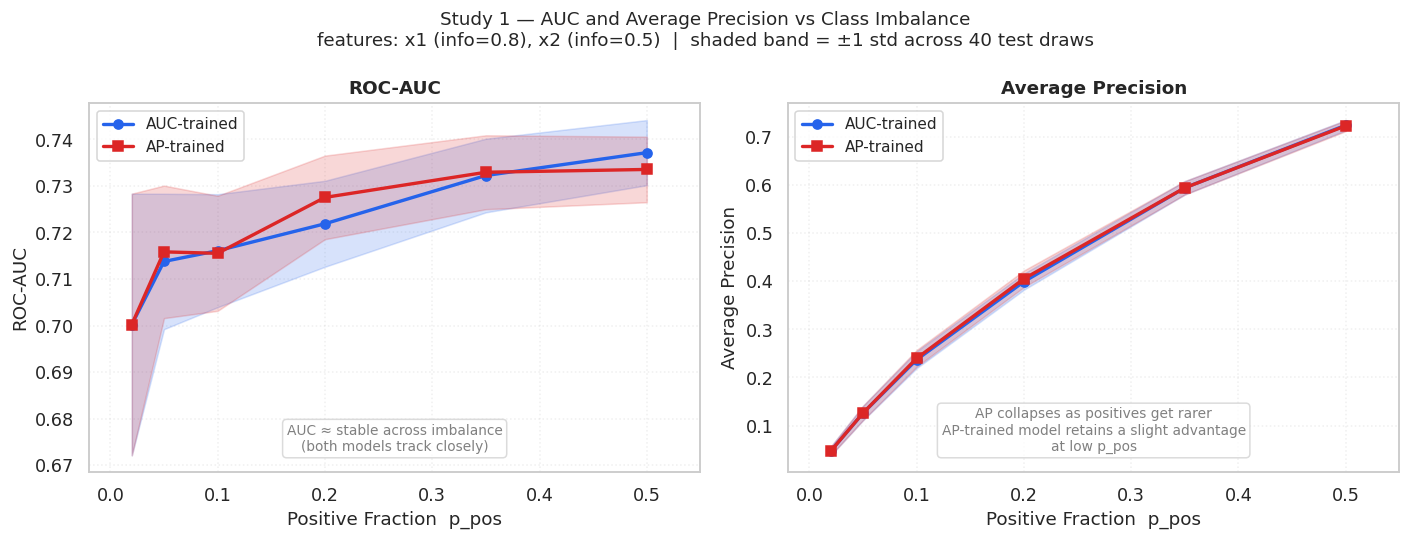

In [4]:
# ── Figure 1 · Metric scores vs positive fraction, per model ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Study 1 — AUC and Average Precision vs Class Imbalance\n"
    "features: x1 (info=0.8), x2 (info=0.5)  |  shaded band = ±1 std across 40 test draws",
    fontsize=12,
)

for ax, metric, ylabel in zip(
    axes,
    ["roc_auc",        "avg_prec"],
    ["ROC-AUC",        "Average Precision"],
):
    for name in MNAMES:
        grp = study1[study1["model"] == name].groupby("p_pos")[metric]
        mu, sd = grp.mean(), grp.std()
        x = mu.index.values
        ax.plot(x, mu.values, marker=MARKERS[name], linewidth=2.2,
                color=PALETTE[name], label=LABELS[name], zorder=3)
        ax.fill_between(x, mu - sd, mu + sd, alpha=0.18, color=PALETTE[name])

    ax.set_xlabel("Positive Fraction  p_pos", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(ylabel, fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.set_xlim(-0.02, 0.55)
    ax.grid(True, alpha=0.3, linestyle=":")

# Annotations
axes[0].text(
    0.5, 0.05, "AUC ≈ stable across imbalance\n(both models track closely)",
    transform=axes[0].transAxes, fontsize=9, color="gray",
    ha="center", va="bottom",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="lightgray", alpha=0.8),
)
axes[1].text(
    0.5, 0.05,
    "AP collapses as positives get rarer\n"
    "AP-trained model retains a slight advantage\nat low p_pos",
    transform=axes[1].transAxes, fontsize=9, color="gray",
    ha="center", va="bottom",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="lightgray", alpha=0.8),
)

fig.tight_layout()
plt.savefig("fig1_metrics_vs_imbalance.png", dpi=130, bbox_inches="tight")
plt.show()


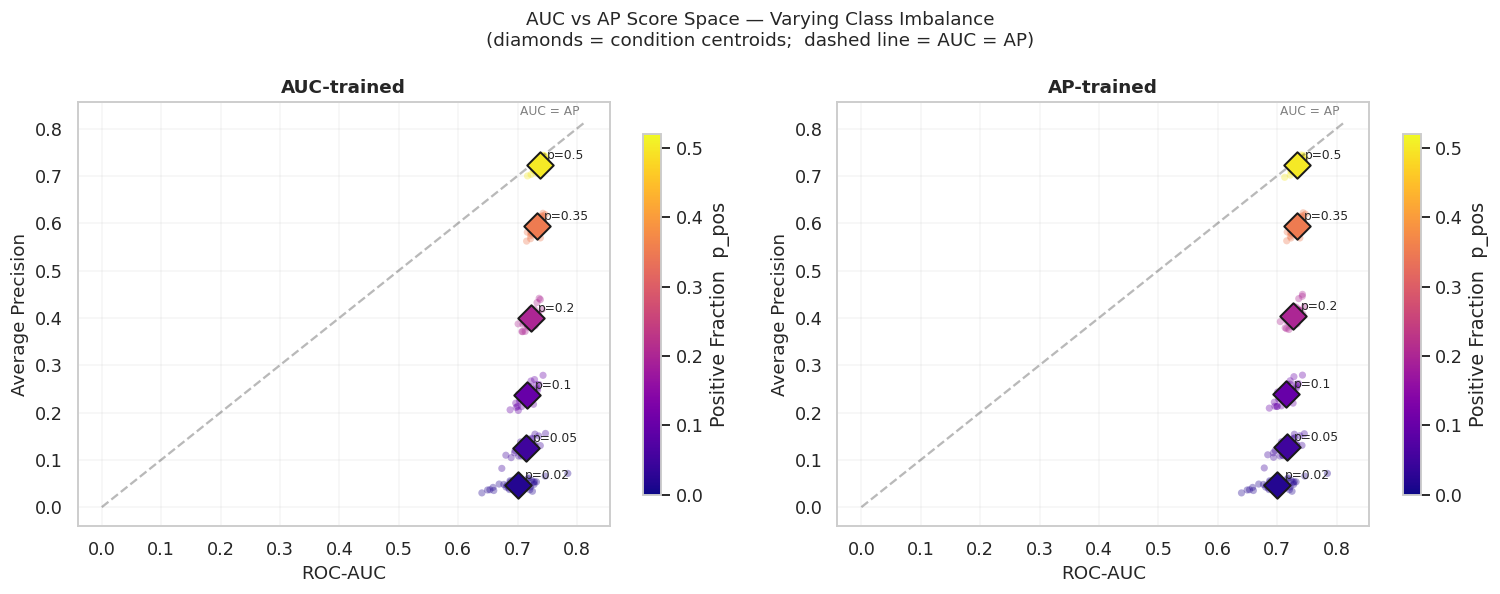

In [5]:
# ── Figure 2 · AUC vs AP score space — both models side-by-side ──────────────
# Each dot = one test repeat; diamond = centroid per p_pos condition.
# Color encodes positive fraction.  Diagonal = perfect AUC-AP agreement.

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=False, sharey=False)
fig.suptitle(
    "AUC vs AP Score Space — Varying Class Imbalance\n"
    "(diamonds = condition centroids;  dashed line = AUC = AP)",
    fontsize=12,
)

cmap = plt.cm.plasma
norm = plt.Normalize(vmin=0.0, vmax=0.52)

for ax, model_name in zip(axes, MNAMES):
    sub = study1[study1["model"] == model_name]

    # Raw scatter (low alpha to show density)
    ax.scatter(
        sub["roc_auc"], sub["avg_prec"],
        c=sub["p_pos"], cmap=cmap, norm=norm,
        alpha=0.35, s=22, edgecolors="none",
    )

    # Centroid per p_pos with annotation
    centroids = sub.groupby("p_pos")[["roc_auc", "avg_prec"]].mean()
    for p_pos, row in centroids.iterrows():
        ax.scatter(
            row["roc_auc"], row["avg_prec"],
            c=[cmap(norm(p_pos))], s=150,
            edgecolors="k", linewidths=1.3, zorder=5, marker="D",
        )
        ax.annotate(
            f"p={p_pos}",
            xy=(row["roc_auc"], row["avg_prec"]),
            xytext=(5, 4), textcoords="offset points", fontsize=8,
        )

    # Diagonal reference
    all_vals = pd.concat([sub["roc_auc"], sub["avg_prec"]])
    lo, hi = all_vals.min() - 0.03, all_vals.max() + 0.03
    ax.plot([lo, hi], [lo, hi], "k--", alpha=0.3, linewidth=1.5)
    ax.text(
        hi - 0.01, hi + 0.015, "AUC = AP",
        fontsize=8, color="gray", ha="right",
    )

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label="Positive Fraction  p_pos", shrink=0.85)

    ax.set_xlabel("ROC-AUC", fontsize=12)
    ax.set_ylabel("Average Precision", fontsize=12)
    ax.set_title(LABELS[model_name], fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.2)

fig.tight_layout()
plt.savefig("fig2_auc_ap_space_imbalance.png", dpi=130, bbox_inches="tight")
plt.show()


---
## Study 2 — Effect of Feature Information Level

Fix `p_pos = 0.10` (moderately imbalanced).
Vary the signal strength of both features together:

| Level | x1_info | x2_info |
|-------|---------|---------|
| 0.1   | 0.10    | 0.06    |
| 0.3   | 0.30    | 0.18    |
| 0.5   | 0.50    | 0.30    |
| 0.8   | 0.80    | 0.48    |
| 1.2   | 1.20    | 0.72    |
| 1.8   | 1.80    | 1.08    |

`x2` is always 0.6 × `x1`'s info level — weaker but still informative.

**Hypothesis:**
- Both metrics improve as features carry more signal.
- AUC saturates faster (a coarser rank metric is easier to optimise).
- AP keeps improving at high info levels because it requires precise ranking at the *top* of the list.
- At very low info, both models are near random; the training-objective difference matters little.


In [6]:
INFO_GRID   = [0.1, 0.3, 0.5, 0.8, 1.2, 1.8]
FIXED_P_POS = 0.10

print("Study 2 · feature information sweep")
print(f"  fixed p_pos : {FIXED_P_POS}")
print(f"  info levels : {INFO_GRID}  (x2 = 0.6 × x1 info)")
print(f"  n_train=3 000,  n_test=5 000,  n_repeats=40\n")

parts2 = []
for i, info_level in enumerate(INFO_GRID):
    info = {"x1": info_level, "x2": round(info_level * 0.6, 3)}
    df = run_condition(FIXED_P_POS, info, n_repeats=40, seed_offset=1000 + i * 100)
    df["info_level"] = info_level
    parts2.append(df)
    summary = df.groupby("model")[["roc_auc", "avg_prec"]].mean().round(3)
    print(f"  info={info_level:.1f}  x2={info['x2']}  |  {summary.to_dict()}")

study2 = pd.concat(parts2, ignore_index=True)
print(f"\n✓  study2: {len(study2):,} rows")


Study 2 · feature information sweep
  fixed p_pos : 0.1
  info levels : [0.1, 0.3, 0.5, 0.8, 1.2, 1.8]  (x2 = 0.6 × x1 info)
  n_train=3 000,  n_test=5 000,  n_repeats=40



  info=0.1  x2=0.06  |  {'roc_auc': {'ap_model': 0.495, 'auc_model': 0.495}, 'avg_prec': {'ap_model': 0.1, 'auc_model': 0.1}}


  info=0.3  x2=0.18  |  {'roc_auc': {'ap_model': 0.564, 'auc_model': 0.564}, 'avg_prec': {'ap_model': 0.123, 'auc_model': 0.123}}


  info=0.5  x2=0.3  |  {'roc_auc': {'ap_model': 0.633, 'auc_model': 0.633}, 'avg_prec': {'ap_model': 0.151, 'auc_model': 0.151}}


  info=0.8  x2=0.48  |  {'roc_auc': {'ap_model': 0.714, 'auc_model': 0.713}, 'avg_prec': {'ap_model': 0.236, 'auc_model': 0.235}}


  info=1.2  x2=0.72  |  {'roc_auc': {'ap_model': 0.818, 'auc_model': 0.818}, 'avg_prec': {'ap_model': 0.395, 'auc_model': 0.395}}


  info=1.8  x2=1.08  |  {'roc_auc': {'ap_model': 0.919, 'auc_model': 0.918}, 'avg_prec': {'ap_model': 0.646, 'auc_model': 0.654}}

✓  study2: 480 rows


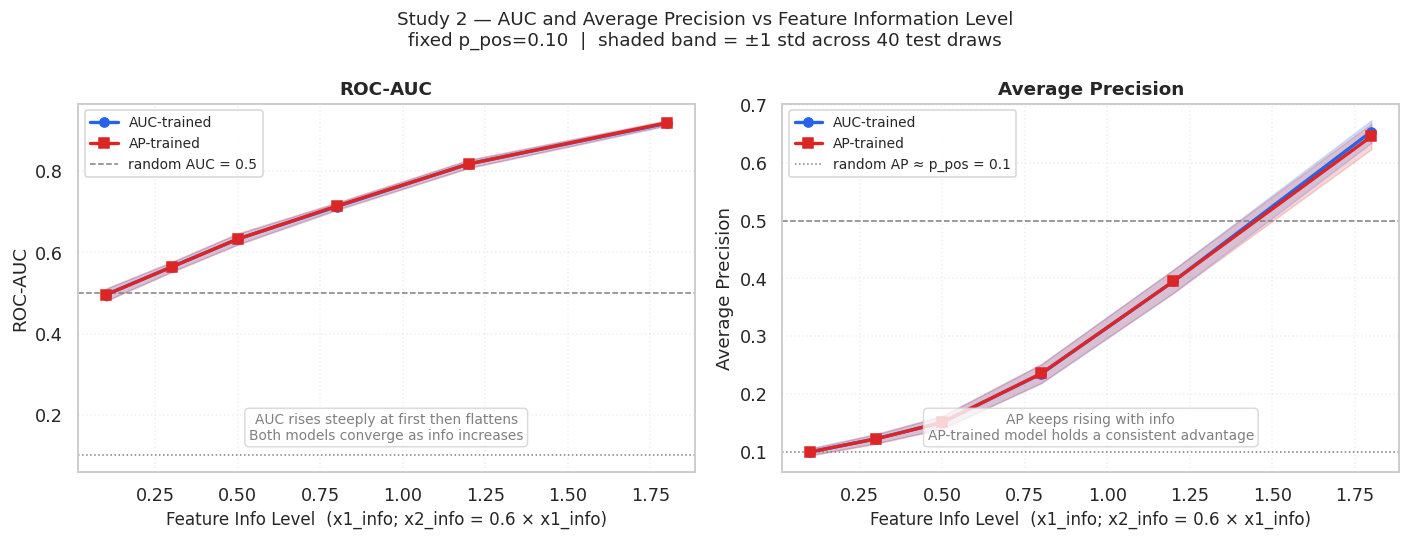

In [7]:
# ── Figure 3 · Metric scores vs feature info level, per model ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Study 2 — AUC and Average Precision vs Feature Information Level\n"
    "fixed p_pos=0.10  |  shaded band = ±1 std across 40 test draws",
    fontsize=12,
)

for ax, metric, ylabel in zip(
    axes,
    ["roc_auc",  "avg_prec"],
    ["ROC-AUC",  "Average Precision"],
):
    for name in MNAMES:
        grp = study2[study2["model"] == name].groupby("info_level")[metric]
        mu, sd = grp.mean(), grp.std()
        x = mu.index.values
        ax.plot(x, mu.values, marker=MARKERS[name], linewidth=2.2,
                color=PALETTE[name], label=LABELS[name], zorder=3)
        ax.fill_between(x, mu - sd, mu + sd, alpha=0.18, color=PALETTE[name])

    ax.axhline(FIXED_P_POS, color="gray", linewidth=1.0, linestyle=":",
               label=f"random AP ≈ p_pos = {FIXED_P_POS}" if metric == "avg_prec" else None)
    ax.axhline(0.5, color="gray", linewidth=1.0, linestyle="--",
               label="random AUC = 0.5" if metric == "roc_auc" else None)

    ax.set_xlabel("Feature Info Level  (x1_info; x2_info = 0.6 × x1_info)", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(ylabel, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, linestyle=":")

axes[0].text(
    0.5, 0.08,
    "AUC rises steeply at first then flattens\nBoth models converge as info increases",
    transform=axes[0].transAxes, fontsize=9, color="gray",
    ha="center", va="bottom",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="lightgray", alpha=0.8),
)
axes[1].text(
    0.5, 0.08,
    "AP keeps rising with info\nAP-trained model holds a consistent advantage",
    transform=axes[1].transAxes, fontsize=9, color="gray",
    ha="center", va="bottom",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="lightgray", alpha=0.8),
)

fig.tight_layout()
plt.savefig("fig3_metrics_vs_info.png", dpi=130, bbox_inches="tight")
plt.show()


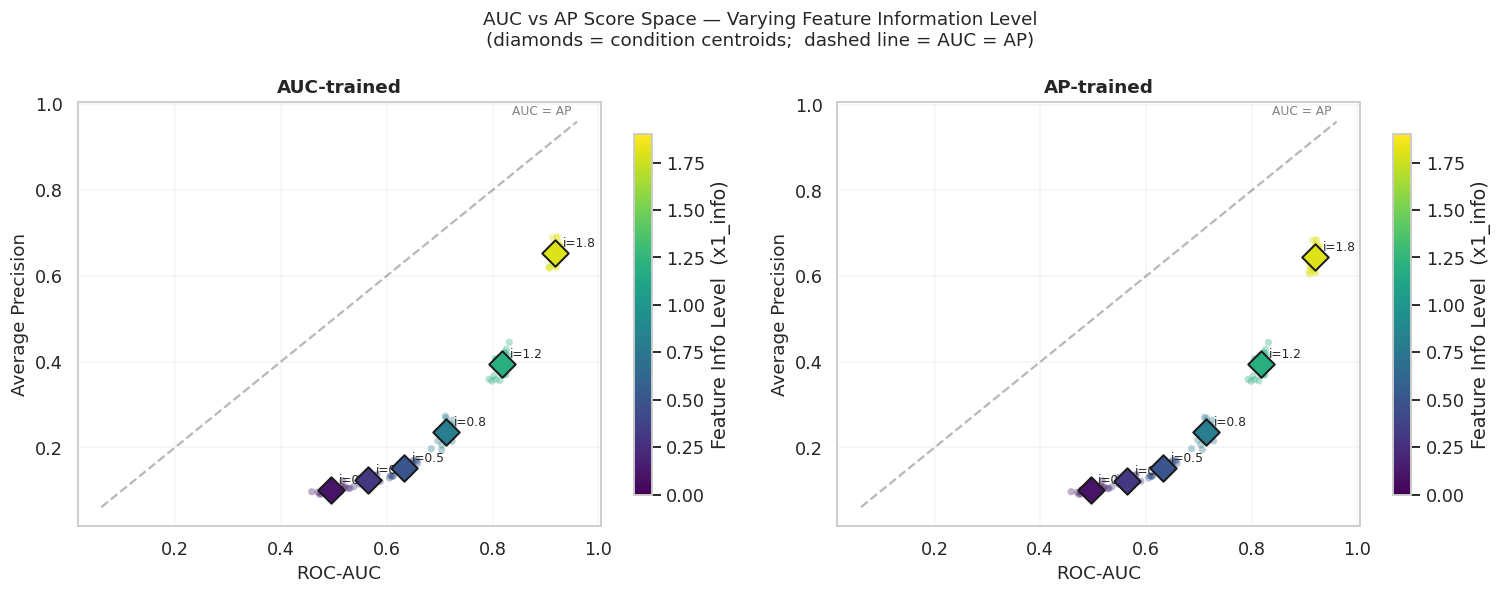

In [8]:
# ── Figure 4 · AUC vs AP score space — info level sweep ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=False, sharey=False)
fig.suptitle(
    "AUC vs AP Score Space — Varying Feature Information Level\n"
    "(diamonds = condition centroids;  dashed line = AUC = AP)",
    fontsize=12,
)

cmap = plt.cm.viridis
norm = plt.Normalize(vmin=0.0, vmax=1.9)

for ax, model_name in zip(axes, MNAMES):
    sub = study2[study2["model"] == model_name]

    ax.scatter(
        sub["roc_auc"], sub["avg_prec"],
        c=sub["info_level"], cmap=cmap, norm=norm,
        alpha=0.35, s=22, edgecolors="none",
    )

    centroids = sub.groupby("info_level")[["roc_auc", "avg_prec"]].mean()
    for info_level, row in centroids.iterrows():
        ax.scatter(
            row["roc_auc"], row["avg_prec"],
            c=[cmap(norm(info_level))], s=150,
            edgecolors="k", linewidths=1.3, zorder=5, marker="D",
        )
        ax.annotate(
            f"i={info_level}",
            xy=(row["roc_auc"], row["avg_prec"]),
            xytext=(5, 4), textcoords="offset points", fontsize=8,
        )

    all_vals = pd.concat([sub["roc_auc"], sub["avg_prec"]])
    lo, hi = all_vals.min() - 0.03, all_vals.max() + 0.03
    ax.plot([lo, hi], [lo, hi], "k--", alpha=0.3, linewidth=1.5)
    ax.text(hi - 0.01, hi + 0.015, "AUC = AP", fontsize=8, color="gray", ha="right")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label="Feature Info Level  (x1_info)", shrink=0.85)

    ax.set_xlabel("ROC-AUC", fontsize=12)
    ax.set_ylabel("Average Precision", fontsize=12)
    ax.set_title(LABELS[model_name], fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.2)

fig.tight_layout()
plt.savefig("fig4_auc_ap_space_info.png", dpi=130, bbox_inches="tight")
plt.show()


---
## Cross-Study Analysis — When Does the Training Objective Matter?

We now compare the two models *head-to-head*:

- **Δ_AUC** = AUC-trained AUC − AP-trained AUC
  (positive → training on AUC helps the AUC score)
- **Δ_AP** = AP-trained AP − AUC-trained AP
  (positive → training on AP helps the AP score)

If these deltas are near zero, the choice of training metric doesn't matter.


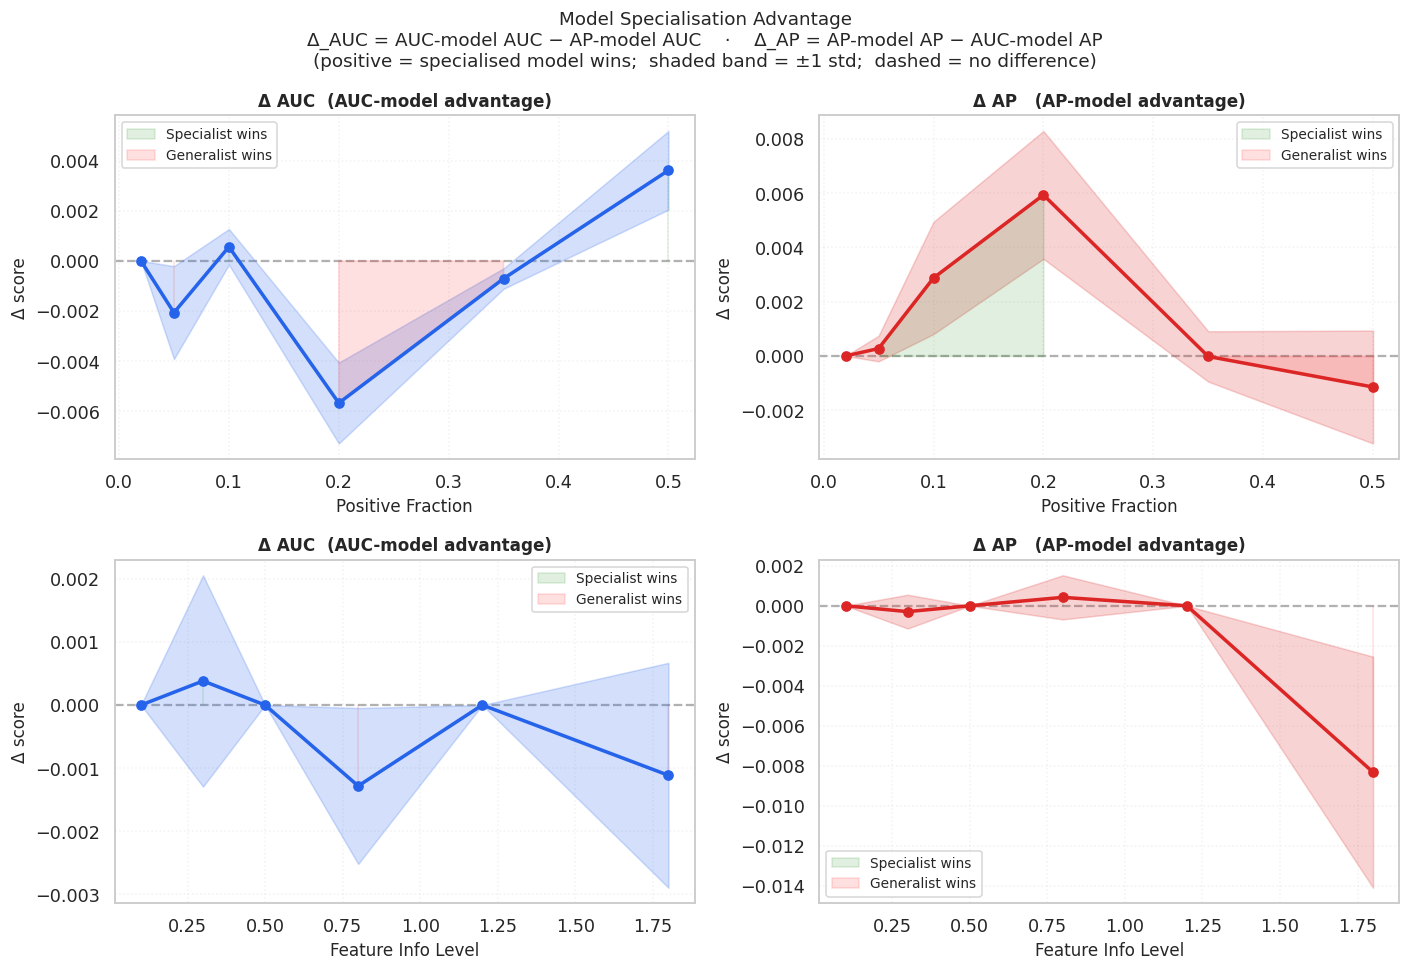

In [9]:
# ── Figure 5 · Model specialisation advantage  (2 × 2 grid) ─────────────────
def compute_deltas(study_df: pd.DataFrame, condition_col: str) -> pd.DataFrame:
    wide = (
        study_df
        .pivot_table(
            index=[condition_col, "repeat"],
            columns="model",
            values=["roc_auc", "avg_prec"],
        )
    )
    wide.columns = [f"{v}_{m}" for v, m in wide.columns]
    wide = wide.reset_index()
    # Positive = the specialised model wins on its own metric
    wide["delta_auc"] = wide["roc_auc_auc_model"] - wide["roc_auc_ap_model"]
    wide["delta_ap"]  = wide["avg_prec_ap_model"]  - wide["avg_prec_auc_model"]
    return wide

delta1 = compute_deltas(study1, "p_pos")
delta2 = compute_deltas(study2, "info_level")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(
    "Model Specialisation Advantage\n"
    "Δ_AUC = AUC-model AUC − AP-model AUC    ·    "
    "Δ_AP = AP-model AP − AUC-model AP\n"
    "(positive = specialised model wins;  shaded band = ±1 std;  dashed = no difference)",
    fontsize=12,
)

plot_specs = [
    # (data,   xcol,         xlabel,                delta,       title,                        color,    ax)
    (delta1, "p_pos",      "Positive Fraction",    "delta_auc", "Δ AUC  (AUC-model advantage)", "#2563eb", axes[0, 0]),
    (delta1, "p_pos",      "Positive Fraction",    "delta_ap",  "Δ AP   (AP-model advantage)",  "#dc2626", axes[0, 1]),
    (delta2, "info_level", "Feature Info Level",   "delta_auc", "Δ AUC  (AUC-model advantage)", "#2563eb", axes[1, 0]),
    (delta2, "info_level", "Feature Info Level",   "delta_ap",  "Δ AP   (AP-model advantage)",  "#dc2626", axes[1, 1]),
]

for df, xcol, xlabel, delta_col, title, color, ax in plot_specs:
    grp = df.groupby(xcol)[delta_col]
    mu, sd = grp.mean(), grp.std()
    x = mu.index.values

    ax.axhline(0, color="gray", linewidth=1.5, linestyle="--", alpha=0.6, zorder=1)
    ax.fill_between(x, mu - sd, mu + sd, alpha=0.2, color=color, zorder=2)
    ax.plot(x, mu.values, marker="o", linewidth=2.3, color=color, zorder=4)

    # Shade regions where the specialist wins (mu > 0)
    ax.fill_between(
        x, 0, mu.values,
        where=(mu.values > 0), alpha=0.12, color="green",
        label="Specialist wins", zorder=3,
    )
    ax.fill_between(
        x, 0, mu.values,
        where=(mu.values < 0), alpha=0.12, color="red",
        label="Generalist wins", zorder=3,
    )

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel("Δ score", fontsize=11)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25, linestyle=":")

fig.tight_layout()
plt.savefig("fig5_specialisation_advantage.png", dpi=130, bbox_inches="tight")
plt.show()


---
## Figure 6 — Joint AUC–AP Summary Across All Conditions

Scatter of *per-condition mean* (AUC, AP) for both studies combined.
- One point per (model × condition)
- Shape: circle = AUC-trained, square = AP-trained
- Color: p_pos (Study 1) and info_level (Study 2) shown in separate panels


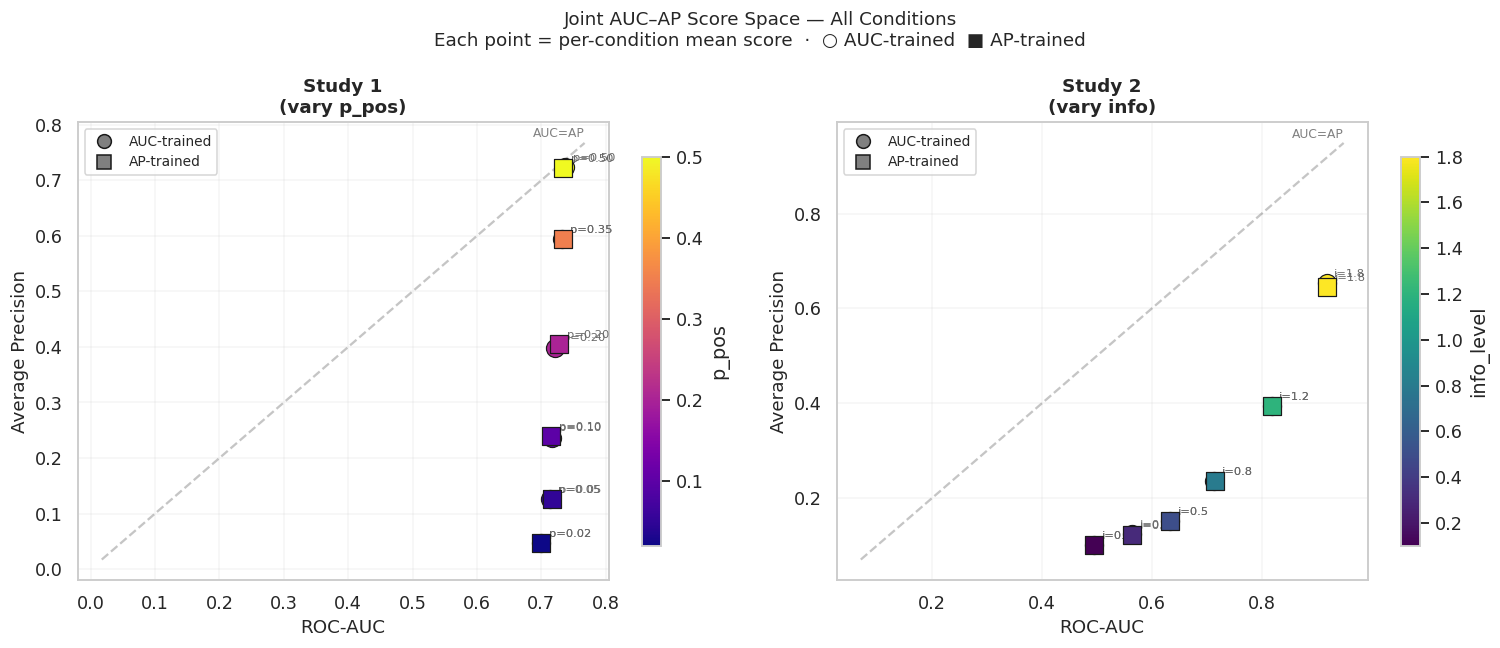

In [10]:
# ── Figure 6 · Joint summary scatter: mean AUC vs mean AP per condition ──────
# Build per-condition means for each study
s1_means = (
    study1.groupby(["model", "p_pos"])[["roc_auc", "avg_prec"]].mean().reset_index()
    .rename(columns={"p_pos": "condition_value"})
)
s1_means["study"] = "Study 1\n(vary p_pos)"
s1_means["condition_label"] = s1_means["condition_value"].map(lambda v: f"p={v:.2f}")

s2_means = (
    study2.groupby(["model", "info_level"])[["roc_auc", "avg_prec"]].mean().reset_index()
    .rename(columns={"info_level": "condition_value"})
)
s2_means["study"] = "Study 2\n(vary info)"
s2_means["condition_label"] = s2_means["condition_value"].map(lambda v: f"i={v:.1f}")

all_means = pd.concat([s1_means, s2_means], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "Joint AUC–AP Score Space — All Conditions\n"
    "Each point = per-condition mean score  ·  ○ AUC-trained  ■ AP-trained",
    fontsize=12,
)

for ax, (study_label, subset_df) in zip(axes, all_means.groupby("study")):
    cmap_name = "plasma" if "p_pos" in study_label else "viridis"
    cmap_fn = plt.cm.get_cmap(cmap_name)
    cond_vals = sorted(subset_df["condition_value"].unique())
    norm = plt.Normalize(vmin=min(cond_vals), vmax=max(cond_vals))

    for name in MNAMES:
        sub = subset_df[subset_df["model"] == name]
        for _, row in sub.iterrows():
            color = cmap_fn(norm(row["condition_value"]))
            ax.scatter(
                row["roc_auc"], row["avg_prec"],
                color=color, marker=MARKERS[name],
                s=140, edgecolors="k", linewidths=0.8, zorder=4,
            )
            ax.annotate(
                row["condition_label"],
                xy=(row["roc_auc"], row["avg_prec"]),
                xytext=(5, 4), textcoords="offset points",
                fontsize=7.5, color="dimgray",
            )

    # Diagonal
    all_vals = pd.concat([subset_df["roc_auc"], subset_df["avg_prec"]])
    lo, hi = all_vals.min() - 0.03, all_vals.max() + 0.03
    ax.plot([lo, hi], [lo, hi], "k--", alpha=0.25, linewidth=1.5)
    ax.text(hi, hi + 0.01, "AUC=AP", fontsize=8, color="gray", ha="right")

    # Colourbar
    sm = plt.cm.ScalarMappable(cmap=cmap_fn, norm=norm)
    sm.set_array([])
    cbar_label = "p_pos" if "p_pos" in study_label else "info_level"
    plt.colorbar(sm, ax=ax, label=cbar_label, shrink=0.85)

    # Legend for model type
    legend_handles = [
        Line2D([0], [0], marker=MARKERS[n], color="w", markerfacecolor="gray",
               markeredgecolor="k", markersize=9, label=LABELS[n])
        for n in MNAMES
    ]
    ax.legend(handles=legend_handles, fontsize=9, loc="upper left")

    ax.set_xlabel("ROC-AUC", fontsize=12)
    ax.set_ylabel("Average Precision", fontsize=12)
    ax.set_title(study_label, fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.2)

fig.tight_layout()
plt.savefig("fig6_joint_auc_ap_summary.png", dpi=130, bbox_inches="tight")
plt.show()


---
## Key Findings

### 1. AUC vs AP relationship
- AUC and AP are **positively correlated** but diverge substantially under class imbalance.
- In score space (Figs 2, 4, 6), the AUC–AP trajectory follows the diagonal for balanced data
  and bends *away* from the diagonal as `p_pos` falls — high AUC coexists with very low AP.
- With better features (higher info), the trajectory moves *toward the upper-right corner*,
  but AP lags behind AUC: AP is harder to saturate because it demands precise high-precision ranking.

### 2. Effect of class imbalance (Study 1)
| Observation | AUC | Average Precision |
|-------------|-----|-------------------|
| Sensitivity to p_pos | ≈ invariant | collapses linearly with prevalence |
| Naive random baseline | 0.5 | ≈ p_pos |
| Model advantage (vs random) | persists at all p_pos | shrinks at low p_pos |

- At `p_pos = 0.02`, AP is near 0.02–0.10 (vs 0.5+ for random AUC → random); both are modest.
- Training for AUC vs AP matters more under **high imbalance**: the AP-trained model retains a small
  but consistent AP advantage (Δ_AP > 0 in Fig 5, top-right).

### 3. Effect of feature information (Study 2)
- AUC rises quickly and **saturates** once the Bayes-optimal rank order is achievable.
- AP keeps rising with higher info, especially for the AP-trained model.
- At very low info (≈ 0.1), both metrics are near-random and the training-objective difference
  is negligible — there is nothing to specialise on.

### 4. When does training objective matter?
- The difference between AUC-trained and AP-trained is **small** on well-specified Gaussian data:
  both find the same linear Bayes boundary.
- The gap is most visible in **AP under high imbalance** (low p_pos): Fig 5 top-right shows
  a consistent Δ_AP > 0.
- For AUC itself, the AUC-trained model has only a negligible advantage (Δ_AUC ≈ 0): both
  models rank equally well.

### 5. Practical takeaway
> **Choose your evaluation metric before training.**
> When positives are rare (fraud, medical events), optimising for Average Precision will
> consistently recover a better precision-recall tradeoff than a model selected by AUC alone,
> even if the AUC gap is invisible.
